# Assignment 2
### Understanding Uncertainty
### Due 9/12

1. 'State Bottle Retail' is the price at which the bottle is sold, while 'State Bottle Cost' is the price the state pays for a bottle.
- How do you define the most profitable item? Why? Explain your thinking.
- Use `.groupby` calculations to determine the most profitable liquors sold in Iowa.
- Make a plot of the top liquors.

- I define profit by the most sold in terms of cash per ml because while a smaller bottle might sell more since it costs less, if you divide the amount by the ml, it ends up being less per ml compared to a bigger bottle that costs more. Sometimes the cost per ml can end up being higher.

<Axes: xlabel='sale_per_volume', ylabel='Item Description'>

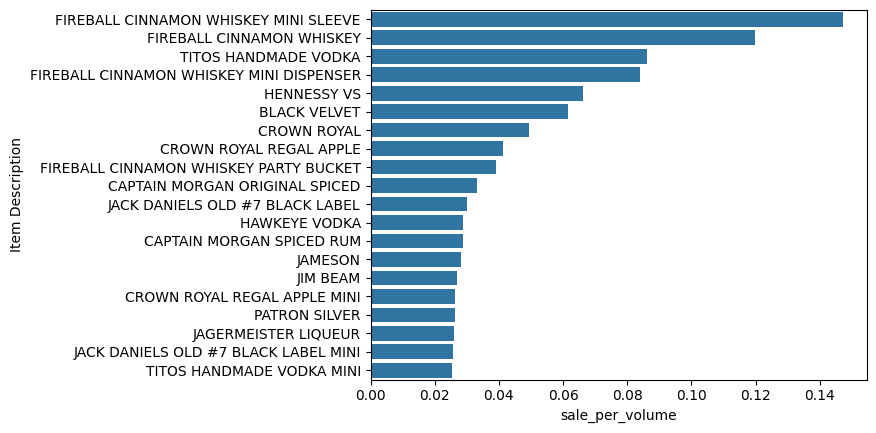

In [ ]:
import numpy as np
import pandas as pd
import math
import seaborn as sns
import matplotlib.pyplot as plt

bottles = pd.read_csv('iowa.csv')
x = bottles['Bottle Volume (ml)']
y = bottles['Sale (Dollars)']
bottles['sale_per_volume'] = y / x

sales =(bottles.loc[:, ['sale_per_volume','Item Description']]
        .groupby('Item Description')
        .sum()
        .sort_values(by ='sale_per_volume', ascending=False))
sales

top_sales = sales[:20]
sns.barplot(top_sales['sale_per_volume']/np.sum(top_sales['sale_per_volume']), orient='h')



2. This question is to further explore broadcasting in NumPy.

- In the first code chunk below, there are two vectors, $x$ and $y$. What happens when you try to subtract them?
- Instead, try `x.reshape(-1,1)-y.reshape(1,-1)`. What do you get?
- Try `x.reshape(1,-1)-y.reshape(-1,1)`. Compare the results to your previous answer.
- Write two double for-loops to replicate the results of the previous two answers. 
- Clearly explain how `x.reshape(1,-1)` and `x.reshape(-1,1)` change $x$

In [ ]:
import numpy as np

x = np.array([1,3,5])
y = np.array([2,5])
l = x -y
l

- I get operands could not be broadcast together with shapes (3,) (2,) 

In [1]:
import numpy as np

x = np.array([1,3,5])
y = np.array([2,5])
l = x.reshape(-1,1)-y.reshape(1,-1)
l

array([[-1, -4],
       [ 1, -2],
       [ 3,  0]])

I get :
array([[-1, -4],
       [ 1, -2],
       [ 3,  0]])

In [3]:
x = [1, 3, 5]
y = [2, 5]

l = []

for i in range(len(x)):         
    row = []                    
    for j in range(len(y)):     
        row.append(x[i] - y[j]) 
    l.append(row)               

l

[[-1, -4], [1, -2], [3, 0]]

x.reshape(-1, 1)  makes x a column becaues the -1 means “figure out how many rows are needed,”
and 1 declares there should be exactly 1 column. So, x becomes a shape of (3, 1) — that’s 3 rows, 1 column (a vertical column). While y.reshape(1,-1) makes y a row The 1 means 1 row, the -1 tells numpy to put as many columns as needed. So, y becomes a shape of (1, 2) — that’s 1 row, 2 columns (a horizontal row).

3. The indicator function $\mathbb{I}\{ x \le z \}$ takes the value 0 if $x>z$ and 1 if $x \le z$ is true, or
$$
\mathbb{I}\{x \le z\} = \begin{cases}
0, &x > z \\
1, &x \le z
\end{cases}
$$

- For $x = 3$, plot the indicator function for any $z$
- Explain how $ 1- \mathbb{I}\{ x \le z \} = \mathbb{I}\{ x > z \}$. Drawing a plot might help, or looking at the definition given above.
- The code below generates a random sample for different numbers of observations, $N = 3, 30, 300, 3000 $. Write a function to compute the ECDF curve for each sample, and plot your results.
- Describe in your own words what happens to the ECDF qualitatively as the sample size $N$ increases

In [ ]:
import matplotlib.pyplot as plt

z = []
x = 3
indicator = []

for num in range(len(z)):
    if x <= z:
        indicator.append(1)
    else:
        indicator.append(0)

plt.plot(indicator, z)
plt.title('Indicator function')
plt.xlabel('z')
plt.ylabel('Indicator value')
plt.show()


The expression $ 1- \mathbb{I}\{ x \le z \} = \mathbb{I}\{ x > z \}$ equal each other because they are the exact opposite. Since an indicator function is 1 for a true condition and 0 for a false one, subtracting an event's indicator from 1 always yields the indicator for its complementary event.

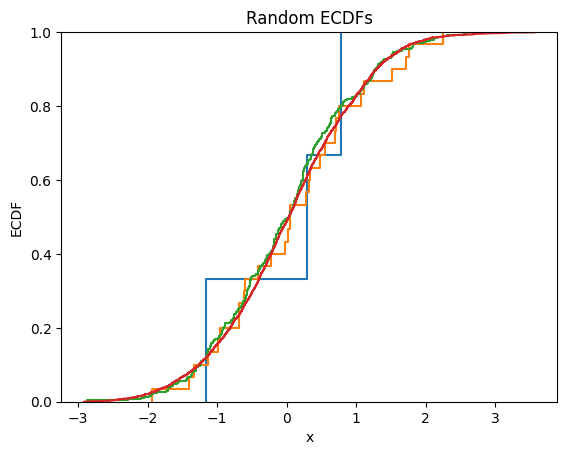

In [ ]:
import numpy as np
import seaborn as sns

rng = np.random.default_rng(100)

for N in (3,30,300,3000):
    X = rng.normal(0,1,N)
    # ECDF plot goes here:
    sns.ecdfplot(data=X, label=f'N = {N}')   

plt.xlabel("x")
plt.ylabel("ECDF")
plt.title("Random ECDFs")
plt.show()


As the sample size N increases, the ECDF becomes smoother and less step-like, to a more smooth curve that follows the shape of the distribution. With larger samples, the ECDF also becomes more stable so if you generated new random samples of the same size, the ECDF curves would be similar to each other compared to the high variability you'd see with very small samples.

4. A **quantile** generalizes the concept of the median so that instead of 50% of the mass below and 50% above, the $q$-quantile is the value for which $q$ proportion of the data are below that value and $(1-q)$ proportion of the data are above that value. This is a concept of **order**.

- Write a function that computes any quantile without using Numpy's `np.quantile`
- Write a function that computes the **Interquartile Range (IQR)** -- the .25 quantile and the .75 quantile, which brackets 50% of the data -- and the **whiskers**: $\pm 1.5 \times \text{IQR}$ from the edges of the IQR
- Write a function that computes a five-number summary and values for a boxplot: the minimum, the .25 quantile, the median, the .75 quantile, and the maximum, and the whiskers
- Anything outside the whiskers is an **outlier**; write a function that returns a Boolean vector indicating if the observations are outliers.
- For a numeric variable of your choice from one of the datasets, apply your functions from above, and compare your answers with `sns.boxplot` and `df.describe`. 

Custom Five-Number Summary for Sale Dollars:
min: -1628.40
Q1: 36.55
median: 78.66
Q3: 152.88
max: 36720.00
lower_whisker: -137.94
upper_whisker: 327.38

Number of outliers: 9534

Pandas describe():
count    159904.000000
mean        146.931598
std         459.368723
min       -1628.400000
25%          36.550000
50%          78.660000
75%         152.880000
max       36720.000000
Name: Sale (Dollars), dtype: float64


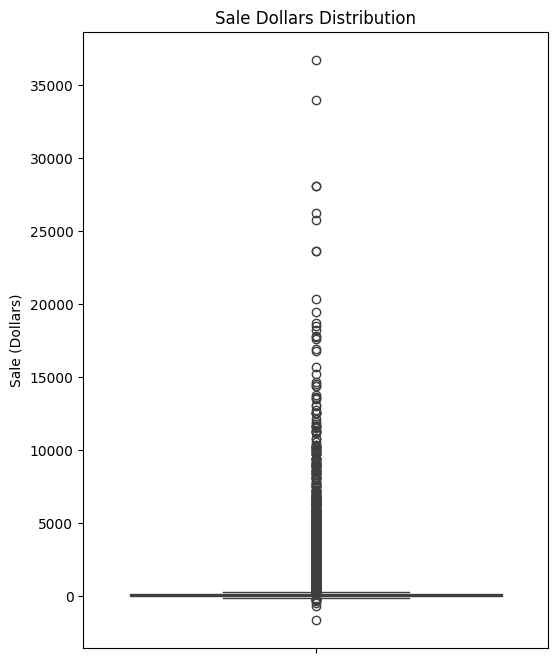

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def compute_quantile(data, q):
    sorted_data = sorted(data)
    n = len(sorted_data)
    
    pos = (n - 1) * q
    lower = int(pos)
    upper = lower + 1
    
    if upper >= n:
        return sorted_data[lower]
    
    weight = pos - lower
    return sorted_data[lower] * (1 - weight) + sorted_data[upper] * weight

def compute_iqr_and_whiskers(data):
    q1 = compute_quantile(data, 0.25)
    q3 = compute_quantile(data, 0.75)
    iqr = q3 - q1
    
    lower_whisker = q1 - 1.5 * iqr
    upper_whisker = q3 + 1.5 * iqr
    
    return q1, q3, lower_whisker, upper_whisker

def five_number_summary(data):
    q1, q3, lower_whisker, upper_whisker = compute_iqr_and_whiskers(data)
    
    return {
        'min': min(data),
        'Q1': q1,
        'median': compute_quantile(data, 0.5),
        'Q3': q3,
        'max': max(data),
        'lower_whisker': lower_whisker,
        'upper_whisker': upper_whisker
    }

def identify_outliers(data):
    q1, q3, lower_whisker, upper_whisker = compute_iqr_and_whiskers(data)
    
    outliers = []
    for value in data:
        if value < lower_whisker or value > upper_whisker:
            outliers.append(True)
        else:
            outliers.append(False)
    
    return outliers

# Example with Iowa Liquor Sales data
df = pd.read_csv('iowa.csv')
data = df['Sale (Dollars)'].dropna().tolist()

summary = five_number_summary(data)
outliers = identify_outliers(data)

print("Custom Five-Number Summary for Sale Dollars:")
for key, value in summary.items():
    print(f"{key}: {value:.2f}")

print(f"\nNumber of outliers: {sum(outliers)}")

# Compare with pandas describe()
print("\nPandas describe():")
print(df['Sale (Dollars)'].describe())

# Compare with seaborn boxplot
plt.figure(figsize=(6, 8))
sns.boxplot(y=df['Sale (Dollars)'])
plt.title('Sale Dollars Distribution')
plt.show()

5. The kernel density estimator captures the concentration of the data around various points, and is defined as
$$
\hat{f}_{N,h}(z) = \frac{1}{N} \sum_{i=1}^N \frac{1}{h} k \left( \frac{x_i - z}{h}\right)
$$
where $h$ is the bandwidth and $k()$ is one of the kernel functions from the class materials (Gaussian, Epanechnikov, uniform, triangular).

- Write a function that takes the bandwidth $h$ as given, and computes and plots $\hat{f}_{N,h}(z)$, for the kernels listed in the slides
- Write a function that computes the plug-in bandwidth
- Use your functions to analyze some numeric variables from a dataset of your choice, using a variety of bandwidths
- Compare bandwidths that are greater or less than the plug-in value with the results for the plug-in value. When does the KDE appear to be overfitting? Underfitting?